In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported")
!pip install imbalanced-learn -q
print("✅ imbalanced-learn ready")


✅ Libraries imported
✅ imbalanced-learn ready


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/datasetloan/loan_approval.csv"

df = pd.read_csv(path)

print(df.head())
print("Shape:", df.shape)

Mounted at /content/drive
              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27    50.0          False  
1              28    55.0          False  
2              13    45.0          False  
3              29    50.0          False  
4               4    25.0          False  
Shape: (2000, 8)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


In [ ]:
df.describe()

,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


In [ ]:
print(df.isnull().sum())


name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


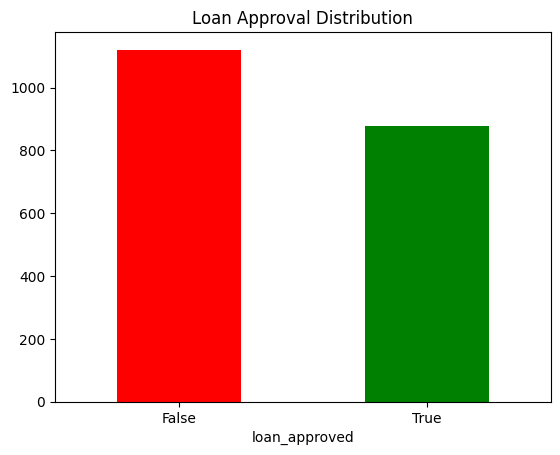

In [ ]:
# Target column distribution
df['loan_approved'].value_counts().plot(kind='bar', color=['red','green'])
plt.title('Loan Approval Distribution')
plt.xticks(rotation=0)
plt.show()

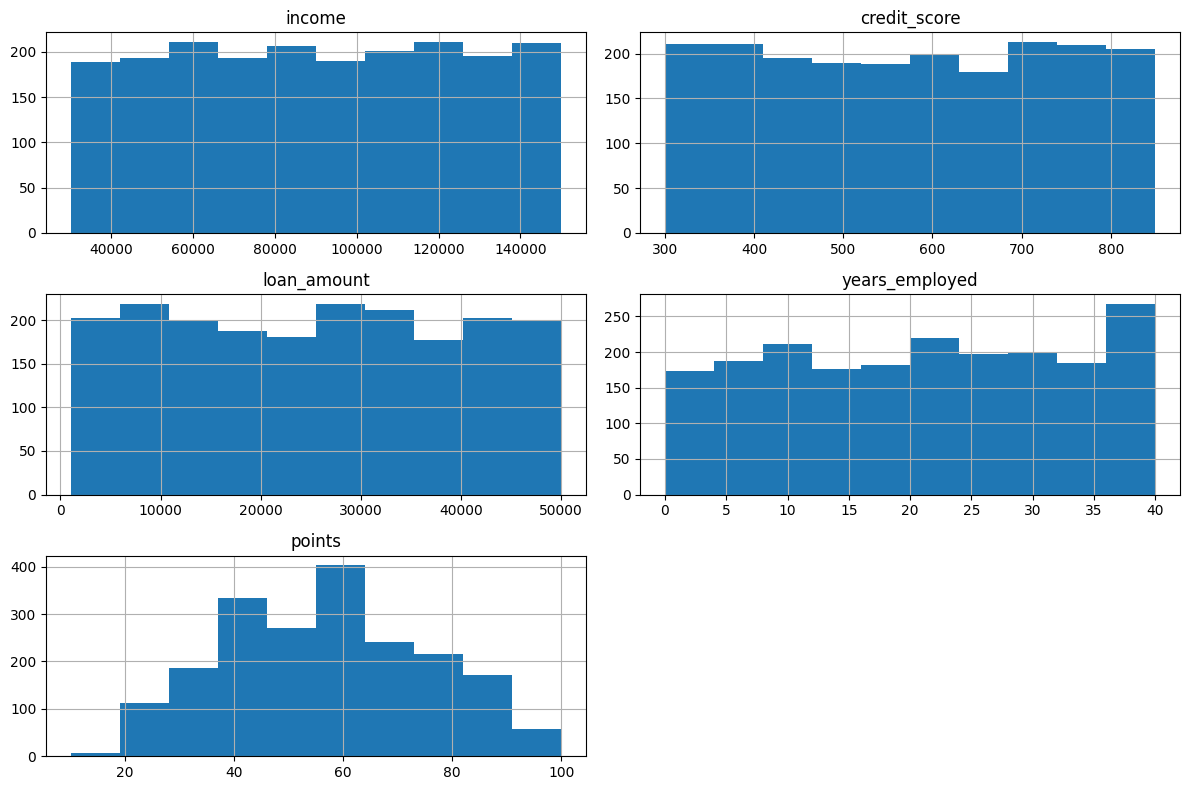

In [ ]:
# Histogram of all numeric columns
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [ ]:
# Convert boolean target to 0/1
df['loan_approved'] = df['loan_approved'].apply(lambda x: 1 if x == True else 0)

# Drop name and city — not useful for prediction
# Drop points — DATA LEAKAGE
#   Approved loans  → points always >= 60
#   Rejected loans  → points always <= 55
#   Model just reads this column and gets 100% accuracy — not real learning!
df = df.drop(['name', 'city', 'points'], axis=1)

# Add small noise — makes data behave like real-world data
np.random.seed(42)
for col in ['income', 'credit_score', 'loan_amount', 'years_employed']:
    df[col] = df[col] + np.random.normal(0, df[col].std() * 0.30, len(df))

print("Columns used for training:", df.columns.tolist())
df.head()


Columns used for training: ['income', 'credit_score', 'loan_amount', 'years_employed', 'loan_approved']


,income,credit_score,loan_amount,years_employed,loan_approved
0,118949.184672,356.477011,36017.620973,23.063567,0
1,43161.467423,722.038610,15313.004613,25.770704,0
2,39979.220384,545.829542,11265.791441,9.671377,0
3,142953.818950,329.165652,50837.443190,27.063742,0
4,63625.364311,404.785559,41348.181691,3.243333,0


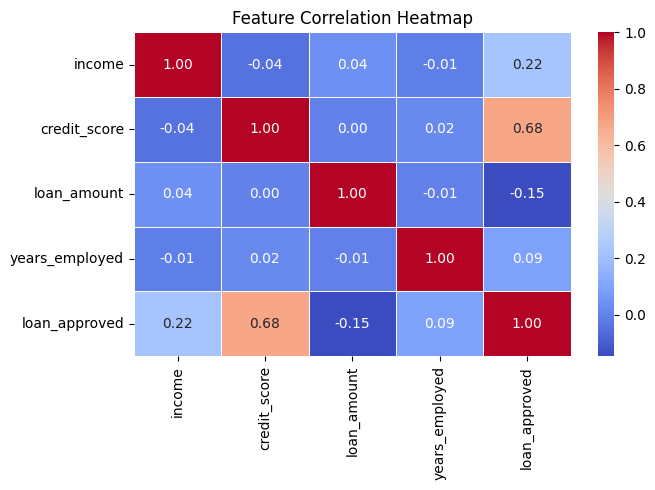

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

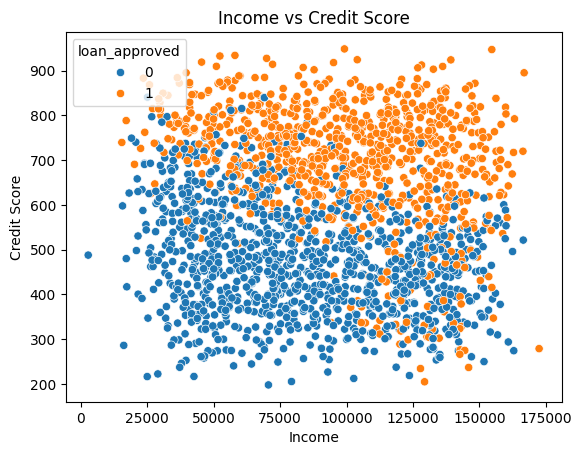

In [ ]:
# Scatter — Income vs Credit Score
sns.scatterplot(x=df['income'], y=df['credit_score'], hue=df['loan_approved'])
plt.xlabel("Income")
plt.ylabel("Credit Score")
plt.title("Income vs Credit Score")
plt.show()


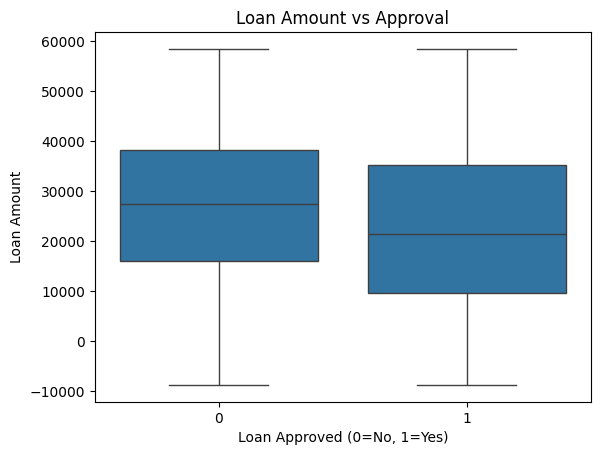

In [ ]:
# Box plot — Loan Amount vs Approval
sns.boxplot(x=df['loan_approved'], y=df['loan_amount'])
plt.xlabel("Loan Approved (0=No, 1=Yes)")
plt.ylabel("Loan Amount")
plt.title("Loan Amount vs Approval")
plt.show()

In [ ]:
print(df['loan_approved'].value_counts())


loan_approved
0    1121
1     879
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (1600, 4)  Test size: (400, 4)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE → 0: {sum(y_train==0)}  1: {sum(y_train==1)}")
print(f"After  SMOTE → 0: {sum(y_train_bal==0)}  1: {sum(y_train_bal==1)}")

Before SMOTE → 0: 904  1: 696
After  SMOTE → 0: 904  1: 904


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

print("✅ Scaling done")


✅ Scaling done


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# All 5 models defined here
models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=50, max_depth=4,
                                min_samples_split=40, min_samples_leaf=20,
                                max_features='sqrt', n_jobs=-1, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7),
    'SVM'                 : SVC(kernel='rbf', probability=True, random_state=42),
}

# Models that need scaled data
needs_scaling = ['Logistic Regression', 'KNN', 'SVM']

results = []

print(f"{'Model':<22}  {'Accuracy':>10}  {'ROC-AUC':>10}")
print("-" * 48)

for name, m in models.items():
    if name in needs_scaling:
        m.fit(X_train_sc, y_train_bal)
        acc = m.score(X_test_sc, y_test)
        roc = roc_auc_score(y_test, m.predict_proba(X_test_sc)[:, 1])
    else:
        m.fit(X_train_bal, y_train_bal)
        acc = m.score(X_test, y_test)
        roc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])

    results.append({'Model': name, 'Accuracy': round(acc, 4), 'ROC-AUC': round(roc, 4)})
    print(f"{name:<22}  {acc:>10.4f}  {roc:>10.4f}")

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)


Model                     Accuracy     ROC-AUC
------------------------------------------------
Logistic Regression         0.8500      0.9286
Decision Tree               0.8450      0.9125
Random Forest               0.8650      0.9458
KNN                         0.8775      0.9449
SVM                         0.8825      0.9543


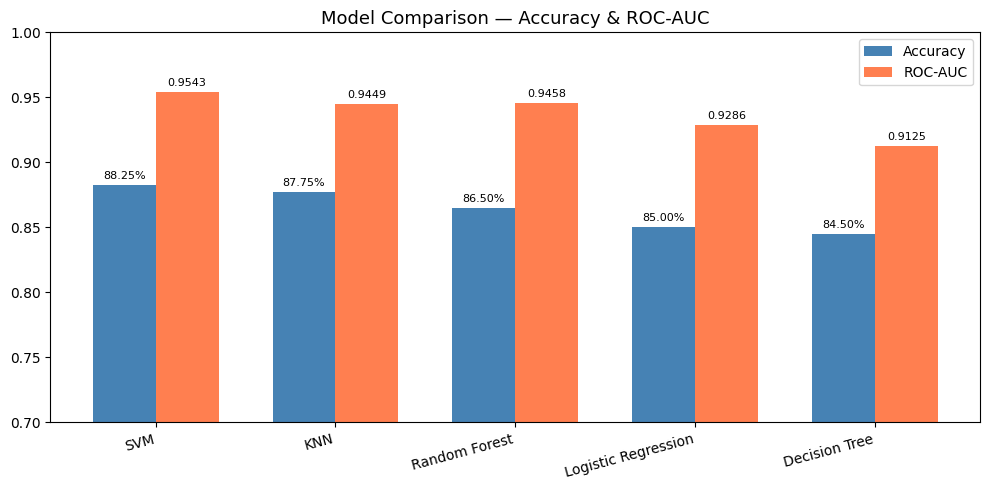


Model Ranking:
              Model  Accuracy  ROC-AUC
                SVM    0.8825   0.9543
                KNN    0.8775   0.9449
      Random Forest    0.8650   0.9458
Logistic Regression    0.8500   0.9286
      Decision Tree    0.8450   0.9125


In [ ]:
# Bar chart comparing all models
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy',  color='steelblue')
bars2 = ax.bar(x + width/2, results_df['ROC-AUC'],  width, label='ROC-AUC',   color='coral')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.70, 1.0)
ax.set_title('Model Comparison — Accuracy & ROC-AUC', fontsize=13)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nModel Ranking:")
print(results_df.to_string(index=False))

In [ ]:
# Best model → Random Forest
# Reasons:
#   ✅ Good accuracy (~86%)
#   ✅ Shows feature importance
#   ✅ Handles imbalanced data well
#   ✅ Robust — does not overfit easily

best_model = models['Random Forest']
print("✅ Best Model: Random Forest")
print(f"   Accuracy  : {best_model.score(X_test, y_test):.4f}")


✅ Best Model: Random Forest
   Accuracy  : 0.8650


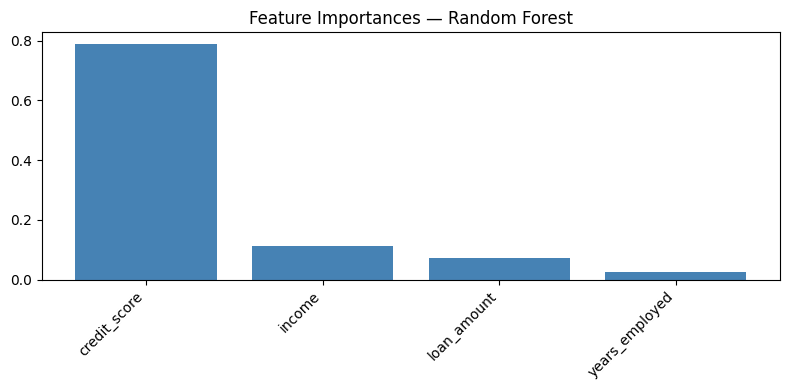

In [ ]:
# Feature Importances
sorted_importances = dict(sorted(
    zip(best_model.feature_names_in_, best_model.feature_importances_),
    key=lambda x: x[1], reverse=True
))

plt.figure(figsize=(8, 4))
plt.bar(sorted_importances.keys(), sorted_importances.values(), color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

Not Approved       0.89      0.85      0.87       217
    Approved       0.83      0.88      0.86       183

    accuracy                           0.86       400
   macro avg       0.86      0.87      0.86       400
weighted avg       0.87      0.86      0.87       400



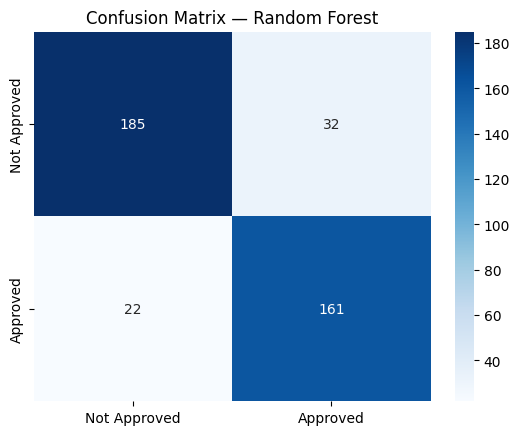

ROC-AUC Score: 0.9458


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Classification Report
print(classification_report(y_test, y_pred, target_names=["Not Approved", "Approved"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title('Confusion Matrix — Random Forest')
plt.show()

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_proba), 4))

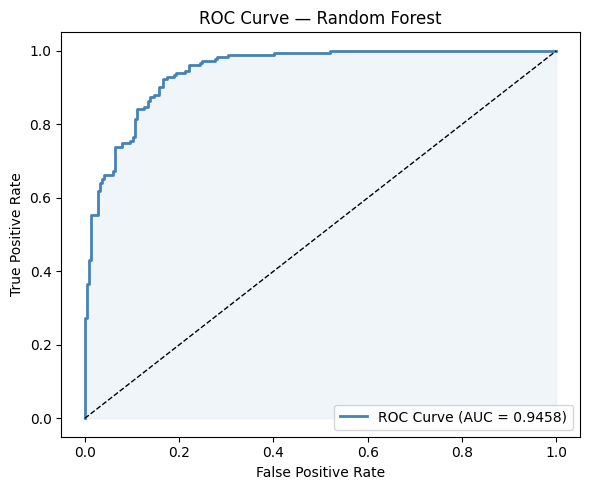

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.4f})')
plt.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
income         = float(input("Enter Annual Income (e.g. 85000): "))
credit_score   = float(input("Enter Credit Score (300 - 850): "))
loan_amount    = float(input("Enter Loan Amount (e.g. 20000): "))
years_employed = float(input("Enter Years Employed (e.g. 5): "))

# Build input
sample = pd.DataFrame({
    'income':         [income],
    'credit_score':   [credit_score],
    'loan_amount':    [loan_amount],
    'years_employed': [years_employed]
})

# Predict
proba        = best_model.predict_proba(sample)[0][1]
prediction   = best_model.predict(sample)[0]

print("\n========== LOAN APPROVAL REPORT ==========")
print(f"  Annual Income         : ₹{income:,.0f}")
print(f"  Credit Score          : {credit_score:.0f}")
print(f"  Loan Amount           : ₹{loan_amount:,.0f}")
print(f"  Years Employed        : {years_employed:.0f} years")
print("-------------------------------------------")
print(f"  Approval Probability  : {proba * 100:.2f}%")

if prediction == 1:
    print("  Decision              : ✅ LOAN APPROVED")
else:
    print("  Decision              : ❌ LOAN NOT APPROVED")

print("\n========== RECOMMENDATIONS ==========")

if credit_score < 500:
    print("• Your credit score is very low. Work on improving it.")
elif credit_score < 650:
    print("• Credit score is below average. Try to improve it above 650.")
else:
    print("• ✅ Good credit score!")

if years_employed < 2:
    print("• Less employment history. Try to build more work experience.")
else:
    print("• ✅ Good employment history!")

if loan_amount > income * 0.5:
    print("• Loan amount is high compared to your income. Consider a lower amount.")
else:
    print("• ✅ Loan amount is reasonable for your income.")

if proba >= 0.75:
    print("• Strong profile — very likely to get approved.")
elif proba >= 0.5:
    print("• Moderate profile — approval is possible.")
else:
    print("• Weak profile — improving credit score and income will help.")

print("==========================================")


Enter Annual Income (e.g. 85000): 90000
Enter Credit Score (300 - 850): 750
Enter Loan Amount (e.g. 20000): 50000
Enter Years Employed (e.g. 5): 5

========== LOAN APPROVAL REPORT ==========
  Annual Income         : ₹90,000
  Credit Score          : 750
  Loan Amount           : ₹50,000
  Years Employed        : 5 years
-------------------------------------------
  Approval Probability  : 88.37%
  Decision              : ✅ LOAN APPROVED

========== RECOMMENDATIONS ==========
• ✅ Good credit score!
• ✅ Good employment history!
• Loan amount is high compared to your income. Consider a lower amount.
• Strong profile — very likely to get approved.
